Searching for TESS light curves...


Cadence 2.0 min | masked 2925 transit points
Cadence 2.0 min | masked 2883 transit points
Cadence 2.0 min | masked 2974 transit points
Cadence 2.0 min | masked 3256 transit points
Cadence 2.0 min | masked 3634 transit points
Cadence 2.0 min | masked 2831 transit points
Cadence 2.0 min | masked 2417 transit points
Cadence 2.0 min | masked 3615 transit points
Cadence 2.0 min | masked 3299 transit points
Cadence 2.0 min | masked 3025 transit points
Cadence 2.0 min | masked 3622 transit points
Cadence 2.0 min | masked 3622 transit points
Cadence 2.0 min | masked 3537 transit points
Cadence 2.0 min | masked 2435 transit points
Cadence 2.0 min | masked 2517 transit points
Cadence 2.0 min | masked 3373 transit points
Cadence 2.0 min | masked 3018 transit points
Cadence 2.0 min | masked 3613 transit points
Cadence 2.0 min | masked 3334 transit points
Cadence 2.0 min | masked 3628 transit points
Cadence 2.0 min | masked 3310 transit points
Cadence 2.0 min | masked 3855 transit points
Cadence 2.

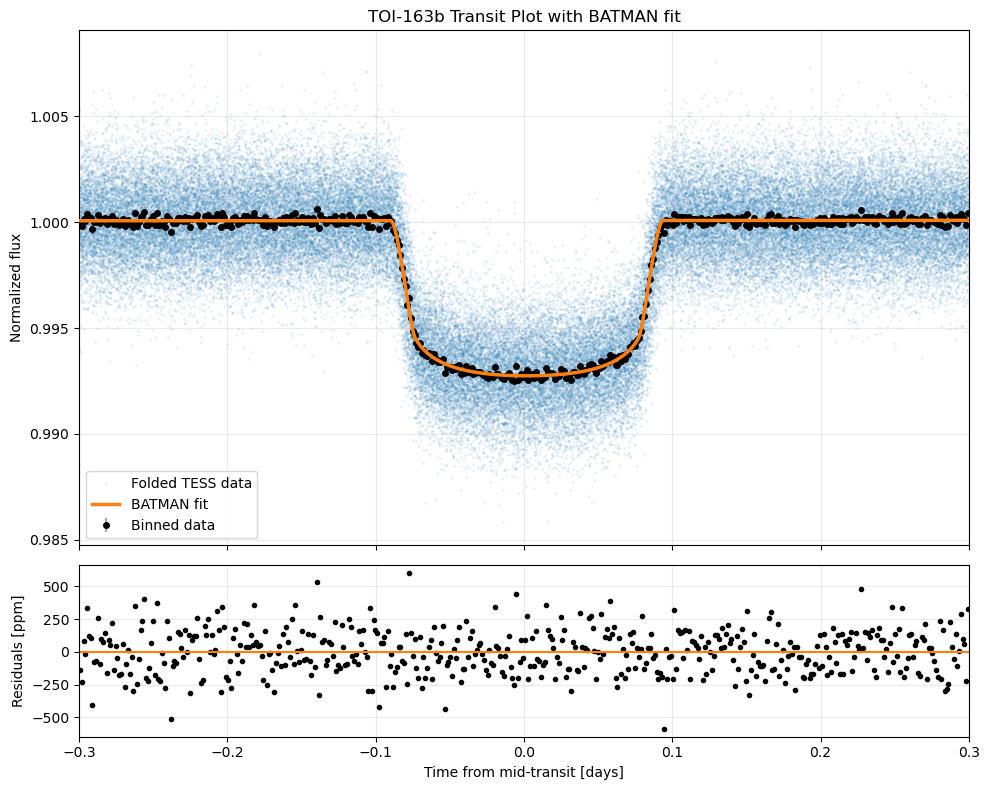

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
import batman

from lightkurve import LightCurveCollection
from scipy.optimize import least_squares


# -----------------------------
# Constants
# -----------------------------

TARGET = "TOI-163"
AUTHOR = "SPOC"

PERIOD = 4.2311043858
T0 = 1544.6718570588
DURATION = 0.16800
A_OVER_RSTAR = 7.52

WINDOW = 0.30
NUMBER_OF_BINS = 500
PREFERRED_CADENCE_SECONDS = 120.0


MIN_T14_DAYS = 0.12
MAX_T14_DAYS = 0.24

U1_PRIOR = 0.25
U2_PRIOR = 0.35
U_SIGMA = 0.30


# -----------------------------
# Download one light curve per sector
# -----------------------------

print("Searching for TESS light curves...")
search = lk.search_lightcurve(TARGET, mission="TESS", author=AUTHOR)

if len(search) == 0:
    raise RuntimeError("No TESS light curves found.")

sectors = {}

for row in range(len(search)):
    sector = int(search.table["sequence_number"][row])
    exptime = search.table["exptime"][row]
    exptime = float(exptime.value if hasattr(exptime, "value") else exptime)

    if np.isfinite(exptime) and exptime < 1:
        exptime *= 24 * 60 * 60

    sectors.setdefault(sector, []).append((row, exptime))

selected_rows = []

for sector in sorted(sectors):
    best_row = min(
        sectors[sector],
        key=lambda x: abs(x[1] - PREFERRED_CADENCE_SECONDS)
        if np.isfinite(x[1])
        else 1e99,
    )
    selected_rows.append(best_row[0])

search = search[selected_rows]

print(f"Downloading {len(search)} light curve files...")
downloaded = search.download_all(quality_bitmask="hard")

if downloaded is None or len(downloaded) == 0:
    raise RuntimeError("No light curves downloaded.")


# -----------------------------
# Clean light curves
# -----------------------------

cleaned = []
mask_half_width = max(2.5 * DURATION, 0.18)

for lc in downloaded:
    try:
        lc = lc.remove_nans().normalize()

        time = np.asarray(lc.time.value, dtype=float)
        cadence_days = np.nanmedian(np.diff(np.sort(time)))

        if not np.isfinite(cadence_days) or cadence_days <= 0:
            raise RuntimeError("Could not measure cadence.")

        flatten_window = max(int(np.ceil(2 / cadence_days)), 101)

        if flatten_window % 2 == 0:
            flatten_window += 1

        phase = ((time - T0 + 0.5 * PERIOD) % PERIOD) - 0.5 * PERIOD
        in_transit = np.abs(phase) < mask_half_width

        print(
            f"Cadence {cadence_days * 24 * 60:.1f} min | "
            f"masked {np.sum(in_transit)} transit points"
        )

        lc = lc.flatten(window_length=flatten_window, polyorder=2, mask=in_transit)
        lc = lc.remove_outliers(sigma=7)

        cleaned.append(lc)

    except Exception as exc:
        print(f"Skipping one sector: {exc}")

if len(cleaned) == 0:
    raise RuntimeError("No light curves survived cleaning.")

lc = LightCurveCollection(cleaned).stitch().remove_nans().normalize()

time = np.asarray(lc.time.value, dtype=float)
flux = np.asarray(lc.flux.value, dtype=float)

good = np.isfinite(time) & np.isfinite(flux)
time = time[good]
flux = flux[good]

cadence_days = np.nanmedian(np.diff(np.sort(time)))

if not np.isfinite(cadence_days) or cadence_days <= 0:
    cadence_days = 30 / (24 * 60)


# -----------------------------
# Fold and bin
# -----------------------------

folded_time = ((time - T0 + 0.5 * PERIOD) % PERIOD) - 0.5 * PERIOD

near_transit = np.abs(folded_time) < WINDOW
folded_time = folded_time[near_transit]
folded_flux = flux[near_transit]

edges = np.linspace(-WINDOW, WINDOW, NUMBER_OF_BINS + 1)

bin_time = []
bin_flux = []
bin_err = []

for left, right in zip(edges[:-1], edges[1:]):
    values = folded_flux[(folded_time >= left) & (folded_time < right)]

    if len(values) < 3:
        continue

    median = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - median))
    scatter = 1.4826 * mad

    if not np.isfinite(scatter) or scatter <= 0:
        scatter = np.nanstd(values)

    if np.isfinite(scatter) and scatter > 0:
        bin_time.append(0.5 * (left + right))
        bin_flux.append(median)
        bin_err.append(scatter / np.sqrt(len(values)))

bin_time = np.array(bin_time)
bin_flux = np.array(bin_flux)
bin_err = np.array(bin_err)

baseline = np.nanmedian(bin_flux[np.abs(bin_time) > 0.65 * WINDOW])
depths = baseline - bin_flux
depth = np.nanpercentile(depths[depths > 0], 98)
rp_guess = np.sqrt(depth)

print()
print("Fixed values")
print("------------")
print(f"Period  = {PERIOD:.10f} days")
print(f"T0      = {T0:.10f} BTJD")
print(f"Duration guess = {DURATION:.5f} days")
print(f"a/Rstar = {A_OVER_RSTAR:.6f}")

print()
print("Folded-transit measurements")
print("---------------------------")
print(f"Points near transit = {len(folded_flux)}")
print(f"Good bins           = {len(bin_flux)}")
print(f"Baseline flux       = {baseline:.7f}")
print(f"Depth estimate      = {depth:.7f}")
print(f"Rp/Rstar guess      = {rp_guess:.5f}")


# -----------------------------
# Fit BATMAN model
# -----------------------------

def model_flux(theta, model_time):
    rp, b, t0_offset, c0, c1, q1, q2 = theta

    if rp <= 0 or b < 0 or b >= 1 + rp:
        return None

    q1 = np.clip(q1, 0, 1)
    q2 = np.clip(q2, 0, 1)

    sqrt_q1 = np.sqrt(q1)
    u1 = 2 * sqrt_q1 * q2
    u2 = sqrt_q1 * (1 - 2 * q2)

    inclination = np.degrees(np.arccos(b / A_OVER_RSTAR))

    params = batman.TransitParams()
    params.t0 = t0_offset
    params.per = PERIOD
    params.rp = rp
    params.a = A_OVER_RSTAR
    params.inc = inclination
    params.ecc = 0
    params.w = 90
    params.u = [u1, u2]
    params.limb_dark = "quadratic"

    transit = batman.TransitModel(
        params,
        model_time,
        supersample_factor=15,
        exp_time=cadence_days,
    ).light_curve(params)

    baseline_model = c0 + c1 * model_time

    return transit * baseline_model


def residuals(theta):
    model = model_flux(theta, bin_time)

    if model is None or not np.all(np.isfinite(model)):
        return np.ones(len(bin_flux) + 3) * 1e20

    rp, b, _, _, _, q1, q2 = theta

    q1 = np.clip(q1, 0, 1)
    q2 = np.clip(q2, 0, 1)

    sqrt_q1 = np.sqrt(q1)
    u1 = 2 * sqrt_q1 * q2
    u2 = sqrt_q1 * (1 - 2 * q2)

    inclination = np.degrees(np.arccos(np.clip(b / A_OVER_RSTAR, 0, 1)))
    sin_i = np.sin(np.radians(inclination))

    t14_arg = np.sqrt(max((1 + rp) ** 2 - b ** 2, 0)) / (A_OVER_RSTAR * sin_i)
    t14 = PERIOD / np.pi * np.arcsin(np.clip(t14_arg, 0, 1))

    duration_penalty = 0

    if t14 < MIN_T14_DAYS:
        duration_penalty = (MIN_T14_DAYS - t14) / 0.015

    if t14 > MAX_T14_DAYS:
        duration_penalty = (t14 - MAX_T14_DAYS) / 0.015

    data_part = (bin_flux - model) / bin_err

    prior_part = np.array([
        (u1 - U1_PRIOR) / U_SIGMA,
        (u2 - U2_PRIOR) / U_SIGMA,
        duration_penalty,
    ])

    return np.concatenate([data_part, prior_part])


initial_guess = np.array([
    rp_guess,
    0.45,
    0.0,
    1.0,
    0.0,
    0.36,
    0.21,
])

lower_bounds = np.array([0.03, 0.0, -0.08, 0.995, -0.05, 0.0, 0.0])
upper_bounds = np.array([0.20, 1.05, 0.08, 1.005, 0.05, 1.0, 1.0])

print()
print("Fitting BATMAN model...")

result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds),
    xtol=1e-12,
    ftol=1e-12,
    gtol=1e-12,
    max_nfev=10000,
)

rp_fit, b_fit, t0_offset_fit, c0_fit, c1_fit, q1_fit, q2_fit = result.x

q1_fit = np.clip(q1_fit, 0, 1)
q2_fit = np.clip(q2_fit, 0, 1)

sqrt_q1 = np.sqrt(q1_fit)
u1_fit = 2 * sqrt_q1 * q2_fit
u2_fit = sqrt_q1 * (1 - 2 * q2_fit)

inc_fit = np.degrees(np.arccos(b_fit / A_OVER_RSTAR))
sin_i = np.sin(np.radians(inc_fit))

t14_arg = np.sqrt(max((1 + rp_fit) ** 2 - b_fit ** 2, 0)) / (A_OVER_RSTAR * sin_i)
t14_fit = PERIOD / np.pi * np.arcsin(np.clip(t14_arg, 0, 1))

if b_fit < 1 - rp_fit:
    t23_arg = np.sqrt(max((1 - rp_fit) ** 2 - b_fit ** 2, 0)) / (A_OVER_RSTAR * sin_i)
    t23_fit = PERIOD / np.pi * np.arcsin(np.clip(t23_arg, 0, 1))
else:
    t23_fit = 0

model_at_bins = model_flux(result.x, bin_time)
data_residuals = (bin_flux - model_at_bins) / bin_err

degrees_of_freedom = max(len(bin_flux) - len(result.x), 1)
reduced_chi2 = np.sum(result.fun ** 2) / degrees_of_freedom
data_reduced_chi2 = np.sum(data_residuals ** 2) / degrees_of_freedom

print()
print("Final BATMAN fit results")
print("------------------------")
print(f"Rp/Rstar           = {rp_fit:.6f}")
print(f"a/Rstar            = {A_OVER_RSTAR:.6f} fixed")
print(f"Impact parameter b = {b_fit:.6f}")
print(f"Inclination        = {inc_fit:.6f} deg")
print(f"T0 offset          = {t0_offset_fit:.6f} days")
print(f"T14                = {t14_fit:.6f} days = {24 * t14_fit:.4f} hours")
print(f"T23                = {t23_fit:.6f} days = {24 * t23_fit:.4f} hours")
print(f"Limb darkening u1  = {u1_fit:.6f}")
print(f"Limb darkening u2  = {u2_fit:.6f}")
print(f"Reduced chi2       = {reduced_chi2:.3f} including priors")
print(f"Data reduced chi2  = {data_reduced_chi2:.3f}")


# -----------------------------
# Plot final fit
# -----------------------------

model_time = np.linspace(-WINDOW, WINDOW, 2500)
best_model = model_flux(result.x, model_time)
residual_ppm = (bin_flux - model_at_bins) * 1e6

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

axes[0].plot(folded_time, folded_flux, ".", color="tab:blue", alpha=0.08, markersize=2, label="Folded TESS data", zorder=1)
axes[0].errorbar(bin_time, bin_flux, yerr=bin_err, fmt="o", color="black", ecolor="0.65", markersize=4, label="Binned data", zorder=2)
axes[0].plot(model_time, best_model, color="tab:orange", linewidth=2.5, label="BATMAN fit", zorder=3)

axes[0].set_ylabel("Normalized flux")
axes[0].set_title("TOI-163b Transit Plot with BATMAN fit")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(bin_time, residual_ppm, "o", color="black", markersize=3)
axes[1].axhline(0, color="tab:orange", linewidth=1.5)
axes[1].set_xlabel("Time from mid-transit [days]")
axes[1].set_ylabel("Residuals [ppm]")
axes[1].set_xlim(-WINDOW, WINDOW)
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.savefig("final-transit-plot.png")
plt.show()
